# **Logistic Regression From Scratch**

## **1. Load and Prepare Data**

In [131]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

In [132]:
raw = load_breast_cancer(as_frame=True)
df = raw.frame
df.head(10)

raw.keys()
raw.data
raw.feature_names
raw.target

df['target'].head(50)

X = df.drop('target' , axis = 1)
y = df['target']

print(y.value_counts())

X_train , X_test , y_train , y_test = train_test_split(

    X,
    y,
    shuffle=True,
    stratify= y,
    random_state=42
)

scaler = StandardScaler(
    copy = True,
    with_std = True,
    with_mean = True
)

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


y_train = y_train.to_numpy()
y_test = y_test.to_numpy()



target
1    357
0    212
Name: count, dtype: int64


## **2. Initialize Parameters**

In [133]:
w = np.zeros(X_train.shape[1])
print(w)
b = 0

learning_rate = 0.01
itr = 1000
m = X_train.shape[0]

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


## **3. Forward Propagation (Prediction)**

In [134]:
def predict(w , b , X_train):

    z = X_train @ w + b
    return 1 / (1 + np.exp(-z))


## **4. Calculate Loss (Cost Function)**

In [135]:
def cross_entropy_loss(y_train, y_hat):
    epsilon = 1e-15

    loss = (
                   -y_train @ np.log(y_hat + epsilon)
                   - (1 - y_train) @ np.log(1 - y_hat + epsilon)   #   Here added epsilon because if y_hat is 0 then it will make -inf and return nan so error
           ) / m

    return loss

## **5. Compute Gradients**

In [136]:
def gradient_w(y_hat , y_train , m , X_train):
    return (X_train.T @ (y_hat - y_train)) / m  # Both gradient function are similar to Linear Regression

def gradient_b(y_hat , y_train , m):
    return np.sum(y_hat - y_train) / m

## **6. Repeat (Training Loop)**

In [137]:

cost = []

for i in range(itr):

    y_hat = predict(w , b , X_train)
    loss = cross_entropy_loss(y_train , y_hat)

    if i <= 1000:
        cost.append(loss)

    dw = gradient_w(y_hat , y_train , m , X_train)
    db = gradient_b(y_hat , y_train, m)

    w = w - learning_rate * dw
    b = b - learning_rate * db




## **7. Store Training History**

Text(0.5, 1.0, 'Loss V/S Iterations')

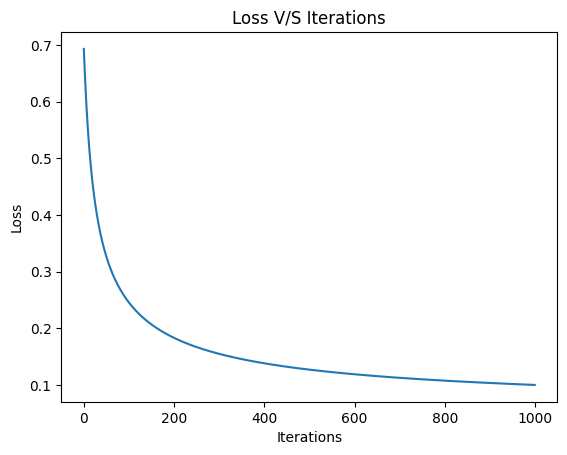

In [138]:
import matplotlib.pyplot as plt

plt.plot(range(len(cost)) , cost)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss V/S Iterations")

## **8. Make Predictions**

In [139]:

y_pred = predict(w , b , X_test)
y_prob = y_pred
y_pred = np.where(y_pred >= 0.5 , 1 , 0)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy :, {accuracy * 100: .2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy :,  97.90%
Precision : 0.9888
Recall    : 0.9778
F1 Score  : 0.9832


## Conclusion

In this notebook, Logistic Regression was implemented completely from scratch using NumPy. The implementation included parameter initialization, the sigmoid activation function, binary cross-entropy loss, gradient computation, gradient descent optimization, prediction, and evaluation metrics.

The model achieved **97.90% accuracy**, along with high precision, recall, and F1-score on the Breast Cancer dataset. When compared with scikit-learn's `LogisticRegression`, the performance was nearly identical, indicating that the mathematical implementation and optimization process are correct.

The small differences in performance arise because the scratch implementation uses Batch Gradient Descent without regularization, whereas scikit-learn uses more advanced optimization algorithms (such as L-BFGS by default) and L2 regularization. Despite these implementation differences, both models converge to similar solutions.

Overall, this implementation provides a strong understanding of the complete training process behind Logistic Regression, including forward propagation, loss computation, gradient calculation, and parameter updates, while demonstrating that a manually implemented model can achieve performance comparable to a well-established machine learning library.


### **Confusion Matrix**

[[52  1]
 [ 2 88]]


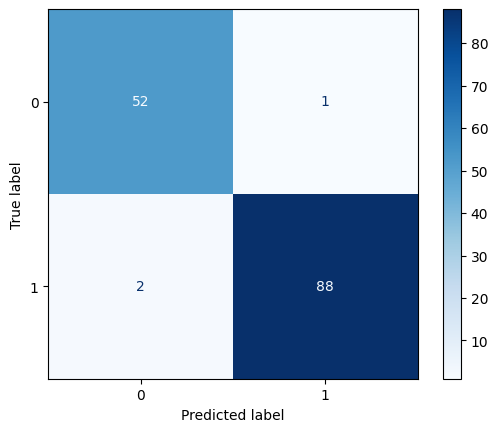

In [140]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=None,
    sample_weight=None,
    normalize=None
)
print(cm)


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap= 'Blues'
)


